In [ ]:
import imageio
import matplotlib.pyplot as plot
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import pandas as pd
import numpy as np

from module.Analysis import *

from skimage import exposure, filters, morphology, measure, color, img_as_float, feature, transform, draw, metrics

/tmp/ipykernel_172185/2084376650.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/165_HC.png")


(540, 800) uint8


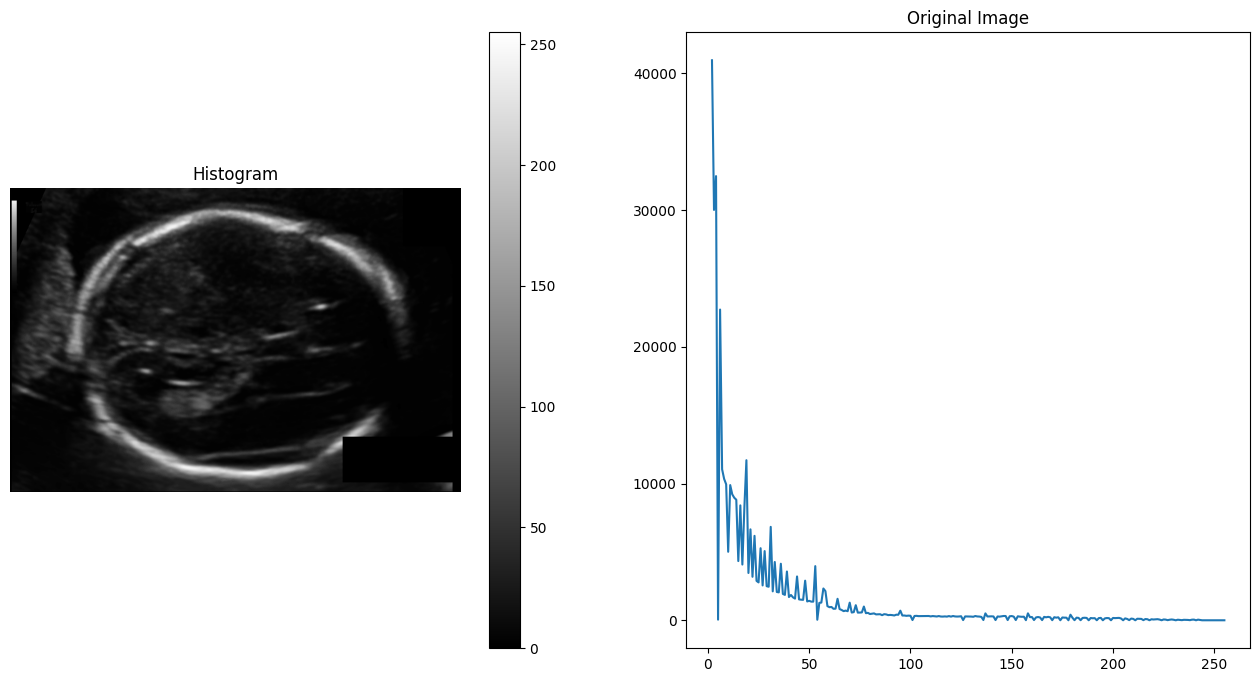

In [4]:
im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/165_HC.png")
# im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/67_HC.png")

hist = ndi.histogram(im, 0, 255, 256)
x = np.arange(2, len(hist))

print(im.shape, im.dtype)
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

im_display = ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Histogram')
ax[0].axis('off')

ax[1].plot(x, hist[2:])
ax[1].set_title('Original Image')

fig.colorbar(im_display, ax=ax[0])

plt.show()

gauss PSNR: 32.03316588481327
MSE: 246.48950462962964
gauss-NM : 0.9638094271992627


Median PSNR: 46.690556385119095
MSE: 3.6089398148148146
Median-NM : 0.9971468656107036


(-0.5, 799.5, 539.5, -0.5)

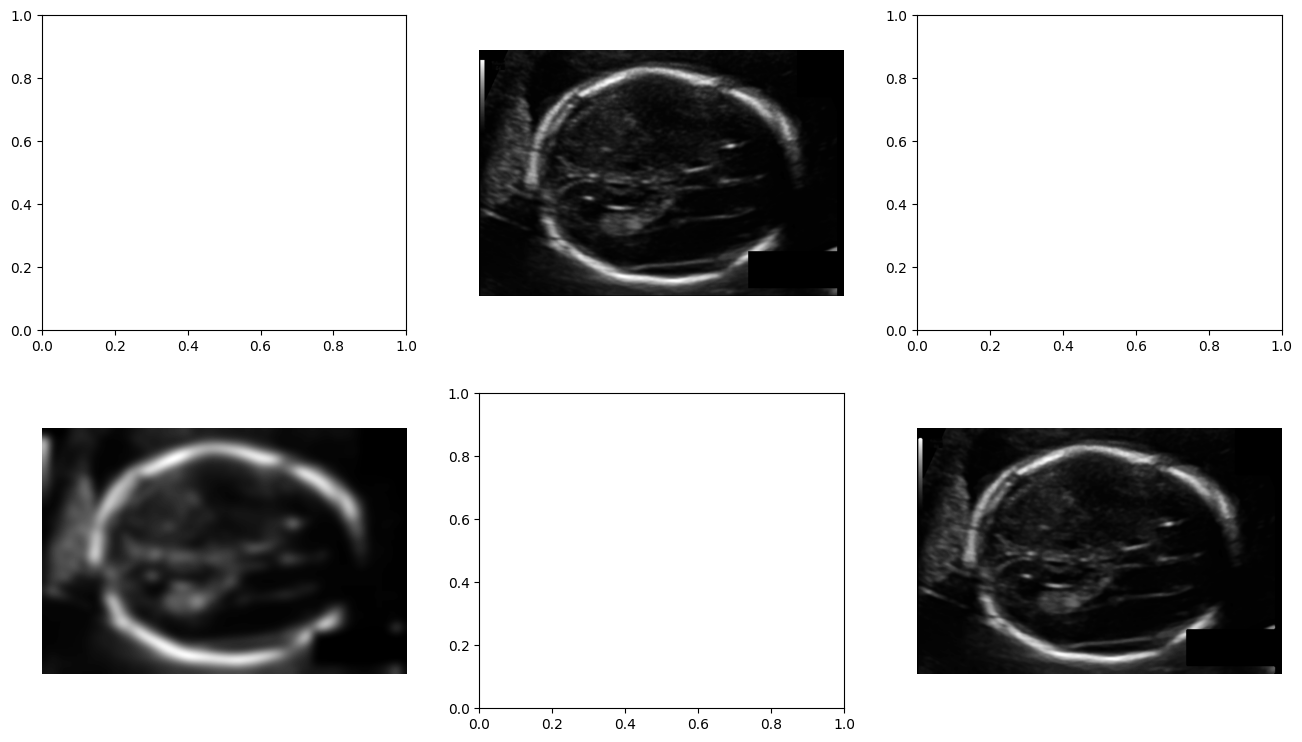

In [11]:
# searching for optimal enchancement
fig, ax = plot.subplots(2, 3, figsize=(16,9))
ax[0,1].imshow(im, cmap="gray"); ax[0,1].axis("off")

im_gaussian = ndi.gaussian_filter(im, sigma=10)
AnalysisPreROI("gauss", im, im_gaussian)

print("\n")
im_median = ndi.median_filter(im, size=(5,5))
AnalysisPreROI("Median", im, im_median)

ax[1,0].imshow(im_gaussian, cmap="gray"); ax[1,0].axis("off")
ax[1,2].imshow(im_median, cmap="gray"); ax[1,2].axis("off")



<function matplotlib.pyplot.show(close=None, block=None)>

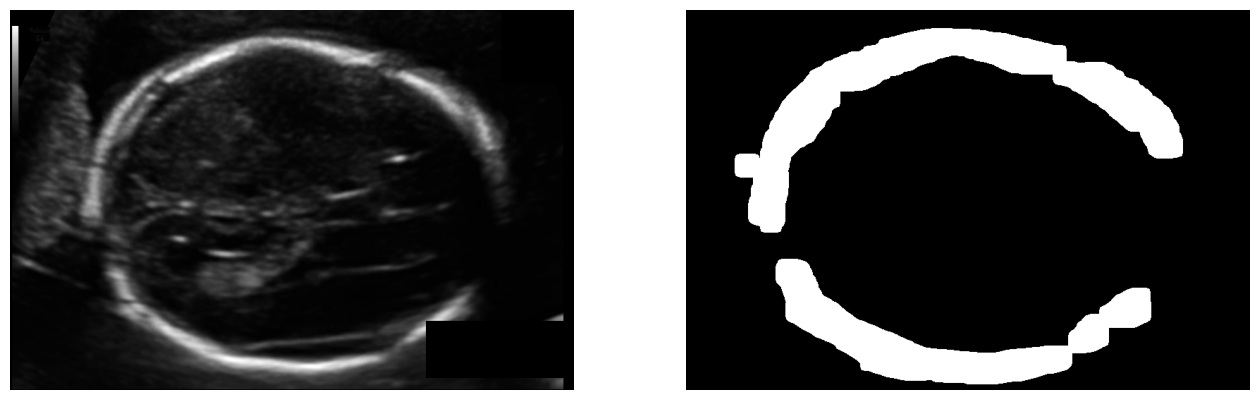

In [6]:
im_filt = ndi.median_filter(im, size=(3,3))

outside = filters.threshold_otsu(im)
inner = im > outside 
inner = morphology.remove_small_objects(inner, 2100)
inner = ndi.binary_fill_holes(inner)

head = morphology.binary_opening(inner, morphology.disk(5))
head = morphology.dilation(head, morphology.square(21))

label = measure.label(head)
props = sorted(measure.regionprops(label), key=lambda r: r.area, reverse=True)
combined = np.zeros_like(head, dtype=bool)
for p in props[:2]: 
    combined |= (label == p.label)
head_merged = morphology.convex_hull_image(combined)

fig, ax = plot.subplots(1, 2, figsize=(16,8))
ax[0].imshow(im, cmap="gray")
ax[0].axis('off')

ax[1].imshow(head, cmap="gray")
ax[1].axis('off')

plot.show

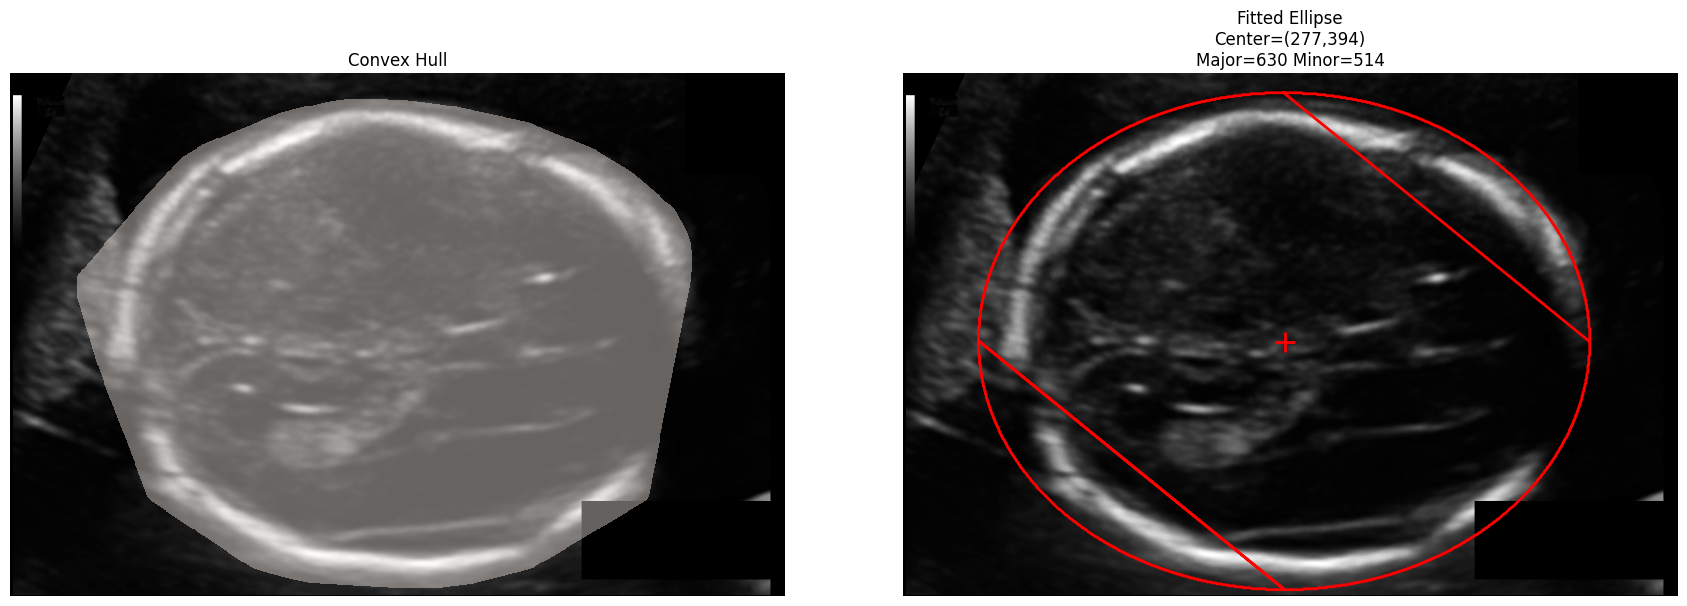

In [7]:
label_merged = measure.label(head_merged.astype(int))
props_merged = measure.regionprops(label_merged)
region = props_merged[0]  


centroid_r = region.centroid[0]     
centroid_c = region.centroid[1]     
semi_major = region.major_axis_length / 2   
semi_minor = region.minor_axis_length / 2   
orientation = region.orientation              

rr, cc = draw.ellipse(
    int(centroid_r), 
    int(centroid_c), 
    int(semi_major),    
    int(semi_major),    
    shape=im.shape,
    rotation=orientation  
)

ellipse_mask = np.zeros_like(im, dtype=bool)
ellipse_mask[rr, cc] = True

rr_p, cc_p = draw.ellipse_perimeter(
    int(centroid_r),
    int(centroid_c),
    int(semi_major),
    int(semi_minor),
    orientation=orientation,
    shape=im.shape
)

fig, ax = plot.subplots(1, 2, figsize=(18, 6))

ax[0].imshow(im, cmap="gray")
ax[0].imshow(np.ma.masked_where(~head_merged, head_merged), cmap="Reds", alpha=0.4)
ax[0].set_title("Convex Hull"); ax[0].axis('off')

ax[1].imshow(im, cmap="gray")
ax[1].plot(cc_p, rr_p, 'r-', linewidth=2)   
ax[1].plot(centroid_c, centroid_r, 'r+', markersize=15, markeredgewidth=2)
ax[1].set_title(f"Fitted Ellipse\n"
                f"Center=({centroid_r:.0f},{centroid_c:.0f})\n"
                f"Major={2*semi_major:.0f} Minor={2*semi_minor:.0f}")
ax[1].axis('off')


plot.tight_layout(); plot.show()


In [8]:
BPD = region.minor_axis_length
OFD = region.major_axis_length
a, b = semi_major, semi_minor
HC = np.pi * (3*(a + b) - np.sqrt((3*a + b) * (a + 3*b)))
cephalic_index = (BPD / OFD) * 100

head_area = region.area
eccentricity = region.eccentricity

cr = int(semi_minor * 0.3)
rr_c, cc_c = draw.ellipse(int(centroid_r), int(centroid_c), cr, cr, shape=im.shape)
cmask = np.zeros_like(im, dtype=bool)
cmask[rr_c, cc_c] = True
cmask &= ellipse_mask

central_mean = np.mean(im[cmask]) if np.any(cmask) else 0
overall_mean = np.mean(im[ellipse_mask])

hpx = im[ellipse_mask].astype(float)

sk = float(np.mean(((hpx-np.mean(hpx))/(np.std(hpx)+1e-6))**3))
ku = float(np.mean(((hpx-np.mean(hpx))/(np.std(hpx)+1e-6))**4))

bb = region.bbox
hcrop = im[bb[0]:bb[2], bb[1]:bb[3]].copy()
mcrop = ellipse_mask[bb[0]:bb[2], bb[1]:bb[3]]
hcrop[~mcrop] = 0
hq = (hcrop // 16).astype(np.uint8)

glcm = feature.graycomatrix(hq, [1,3,5], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                     levels=16, symmetric=True, normed=True)

contrast    = feature.graycoprops(glcm, 'contrast').mean()
dissim      = feature.graycoprops(glcm, 'dissimilarity').mean()
homogeneity = feature.graycoprops(glcm, 'homogeneity').mean()
energy      = feature.graycoprops(glcm, 'energy').mean()
correlation = feature.graycoprops(glcm, 'correlation').mean()

In [9]:
data = {
    "BPD": BPD,
    "OFD": OFD,
    "HC": HC,
    "Cephalic_Index": cephalic_index,
    "Head_Area": head_area,
    "Eccentricity": eccentricity,
    
    "Central_Mean_Intensity": central_mean,
    "Overall_Mean_Intensity": overall_mean,
    
    "Skewness": sk,
    "Kurtosis": ku,
    
    "GLCM_Contrast": contrast,
    "GLCM_Dissimilarity": dissim,
    "GLCM_Homogeneity": homogeneity,
    "GLCM_Energy": energy,
    "GLCM_Correlation": correlation
}

df = pd.DataFrame([data])

df

,BPD,OFD,HC,Cephalic_Index,Head_Area,Eccentricity,Central_Mean_Intensity,Overall_Mean_Intensity,Skewness,Kurtosis,GLCM_Contrast,GLCM_Dissimilarity,GLCM_Homogeneity,GLCM_Energy,GLCM_Correlation
0,513.6359,630.004015,1801.078238,81.528988,253187.0,0.579053,22.774206,33.31999,2.250429,8.203344,0.629511,0.321949,0.864845,0.509818,0.949685
